In [11]:
import subprocess
import os
import numpy as np
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
import pickle
import pprint
import lzma

In [12]:
subprocess.run(["g++", "generate-variate-graph.cpp", "-O3", "-o", "generate-variate-graph"], check=True, text=True, capture_output=True)

CompletedProcess(args=['g++', 'generate-variate-graph.cpp', '-O3', '-o', 'generate-variate-graph'], returncode=0, stdout='', stderr='')

In [13]:
def save_graph_nx(graph: nx.Graph, filename: str) -> None:
    try:
        with open(filename, "w") as f:
            for edge in graph.edges():
                f.write(f"{edge[0] + 1} {edge[1] + 1}\n")
    except Exception as e:
        print(f"Error saving graph to {filename}: {e}")

def load_graph_nx(filename: str) -> nx.Graph:
    graph = nx.Graph()
    try:
        with open(filename, "r") as f:
            for line in f:
                u, v = map(int, line.strip().split())
                graph.add_edge(u, v)
    except Exception as e:
        print(f"Error loading compressed graph from {filename}: {e}")
    return graph

def save_compressed_graph_nx(graph: nx.Graph, filename: str) -> None:
    try:
        with lzma.open(filename, "wt") as f:
            for edge in graph.edges():
                f.write(f"{edge[0] + 1} {edge[1] + 1}\n")
    except Exception as e:
        print(f"Error saving compressed graph to {filename}: {e}")

def load_compressed_graph_nx(filename: str) -> nx.Graph:
    graph = nx.Graph()
    try:
        with lzma.open(filename, "rt") as f:
            for line in f:
                u, v = map(int, line.strip().split())
                graph.add_edge(u - 1, v - 1)
    except Exception as e:
        print(f"Error loading compressed graph from {filename}: {e}")
    return graph

def relabel_graph_nx(graph: nx.Graph) -> nx.Graph:
    mapping = {old_label: new_label for new_label, old_label in enumerate(graph.nodes())}
    return nx.relabel_nodes(graph, mapping)

def count_subgraphs(graph: nx.Graph, subgraph: nx.Graph, nthreads: int) -> int:
    save_graph_nx(relabel_graph_nx(graph), "graph.txt")
    save_graph_nx(relabel_graph_nx(subgraph), "subgraph.txt")

    try:
        result = subprocess.run(
            ["./peregrine/bin/count", "graph.txt", "subgraph.txt", str(nthreads)],
            check=True,
            text=True,
            capture_output=True,
        )
        
        os.remove("graph.txt")
        os.remove("subgraph.txt")

        return int(result.stdout.split(":")[2].strip())
    except:
        os.remove("graph.txt")
        os.remove("subgraph.txt")
        
        print("Error occurred while counting subgraphs")
        return -1

In [14]:
def generate_variate_graph(n: int, m: int, p: float, alpha: float | None = None, graph_type: str = "standard", file_identifier: str = "") -> nx.Graph:
    if graph_type == "standard":
        graph_type = "0"
    elif graph_type == "power-based":
        if alpha is None:
            print("Alpha parameter must be provided for power-based graph type")
            return None
        graph_type = "1"
    elif graph_type == "log-based":
        graph_type = "2"
    else:
        print(f"Graph type {graph_type} is not supported")
        return None

    result = subprocess.run(
            ["./generate-variate-graph", str(n), str(m), str(p), graph_type, f"graph_{file_identifier}.txt"] if alpha is None else
            ["./generate-variate-graph", str(n), str(m), str(p), graph_type, f"graph_{file_identifier}.txt", str(alpha)],
            check=True,
            text=True,
            capture_output=True,
        )
    
    if result.returncode != 0:
        print(f"Error generating graph: {result.stderr}")
        return None

    g = load_graph_nx(f"graph_{file_identifier}.txt")
    os.remove(f"graph_{file_identifier}.txt")
    
    return g

In [15]:
def calculate_empirical_nodes_connection_probability(gen_graph_func: callable, reps: int) -> defaultdict:
    count_matrix = defaultdict(int)
    
    for _ in range(reps):
        G = gen_graph_func()

        for u, v in G.edges():
            count_matrix[tuple(sorted((u, v)))] += 1

    count_matrix_sum = sum(count_matrix.values())
    probability_matrix = defaultdict(float)
    for edge, count in count_matrix.items():
        probability_matrix[edge] = count / count_matrix_sum
    
    return probability_matrix

In [16]:
def calculate_empirical_degrees_connection_probability(gen_graph_func: callable, reps: int) -> defaultdict:
    degree_count_matrix = defaultdict(int)

    for _ in range(reps):
        G = gen_graph_func()
        
        for u, v in G.edges():
            deg_u = G.degree(u)
            deg_v = G.degree(v)
            degree_count_matrix[tuple(sorted((deg_u, deg_v)))] += 1

    degree_count_matrix_sum = sum(degree_count_matrix.values())
    degree_probability_matrix = defaultdict(float)
    for deg_pair, count in degree_count_matrix.items():
        degree_probability_matrix[deg_pair] = count / degree_count_matrix_sum

    return degree_probability_matrix

In [41]:
def visualize_matrix(matrix: defaultdict, selected_degrees_for_slices: list[int], title: str, xlabel: str, ylabel: str, max_key: int = None):
    if not matrix:
        print("Matrix is empty. Nothing to visualize.")
        return
    
    keys_pairs = list(matrix.keys())
    
    if max_key is None:
        max_val_in_keys = 0
        for k1, k2 in keys_pairs:
            max_val_in_keys = max(max_val_in_keys, k1, k2)
        max_key = max_val_in_keys
        
    size = max_key + 1
   
    mat = np.zeros((size, size))
    for (key1, key2), value in matrix.items():
        if key1 <= max_key and key2 <= max_key:
            mat[key1, key2] = value
            mat[key2, key1] = value  # Ensure symmetry

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ax_heatmap = axes[0]
    ax_lines = axes[1]

    im = ax_heatmap.imshow(mat, cmap='viridis', interpolation='nearest', origin='lower')
    fig.colorbar(im, ax=ax_heatmap, label='Value')
    ax_heatmap.set_title(f"{title} - histogram")
    ax_heatmap.set_xlabel(xlabel)
    ax_heatmap.set_ylabel(ylabel)
    ax_heatmap.set_xlim(-0.5, max_key + 0.5)
    ax_heatmap.set_ylim(-0.5, max_key + 0.5)


    x = np.arange(size)
    for i, fixed_degree in enumerate(selected_degrees_for_slices):
        if fixed_degree >= size:
            print(f"Warning: Degree {fixed_degree} is out of the degree bounds")
            continue

        y_slice = mat[:, fixed_degree]
        ax_lines.plot(x, y_slice, label=f'{ylabel} = {fixed_degree}', linewidth=2, marker='o', markersize=4)

    ax_lines.set_title(f"{title} - plot")
    ax_lines.set_xlabel(xlabel)
    ax_lines.set_ylabel("Probability")
    ax_lines.set_xlim(0, max_key)
    ax_lines.grid(True, linestyle='--', alpha=0.7)
    ax_lines.legend(title="Selected degrees")

    plt.show()

### Preferential Attachment

In [18]:
empirical_nodes_connection_probability = calculate_empirical_nodes_connection_probability(lambda: generate_variate_graph(1000, 3, 1, graph_type="standard"), 10000)
with open('generated-data/without-acceptance/preferential-attachment/empirical_nodes_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_nodes_connection_probability, f)

empirical_degrees_connection_probability = calculate_empirical_degrees_connection_probability(lambda: generate_variate_graph(1000, 3, 1, graph_type="standard"), 10000)
with open('generated-data/without-acceptance/preferential-attachment/empirical_degrees_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_degrees_connection_probability, f)

empirical_nodes_connection_probability = calculate_empirical_nodes_connection_probability(lambda: generate_variate_graph(1000, 3, 0.6, graph_type="standard"), 10000)
with open('generated-data/with-acceptance/preferential-attachment/empirical_nodes_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_nodes_connection_probability, f)

empirical_degrees_connection_probability = calculate_empirical_degrees_connection_probability(lambda: generate_variate_graph(1000, 3, 0.6, graph_type="standard"), 10000)
with open('generated-data/with-acceptance/preferential-attachment/empirical_degrees_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_degrees_connection_probability, f)

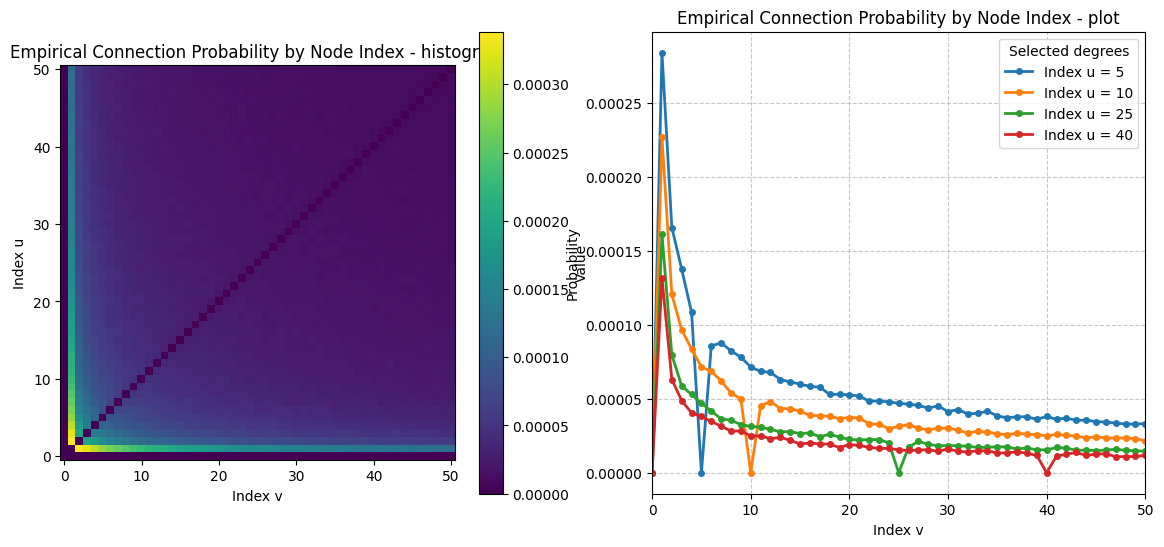

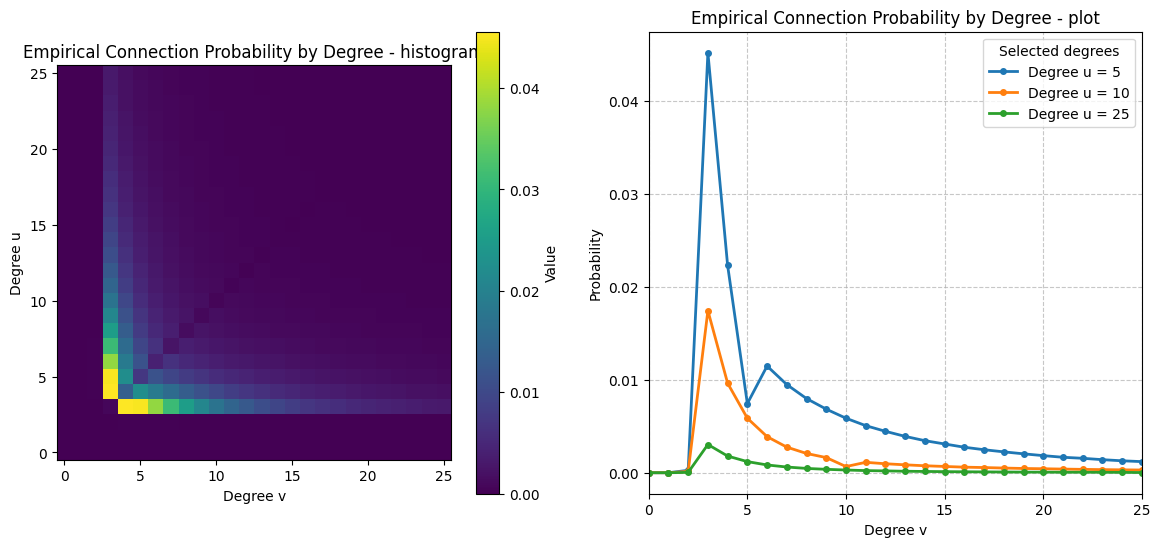

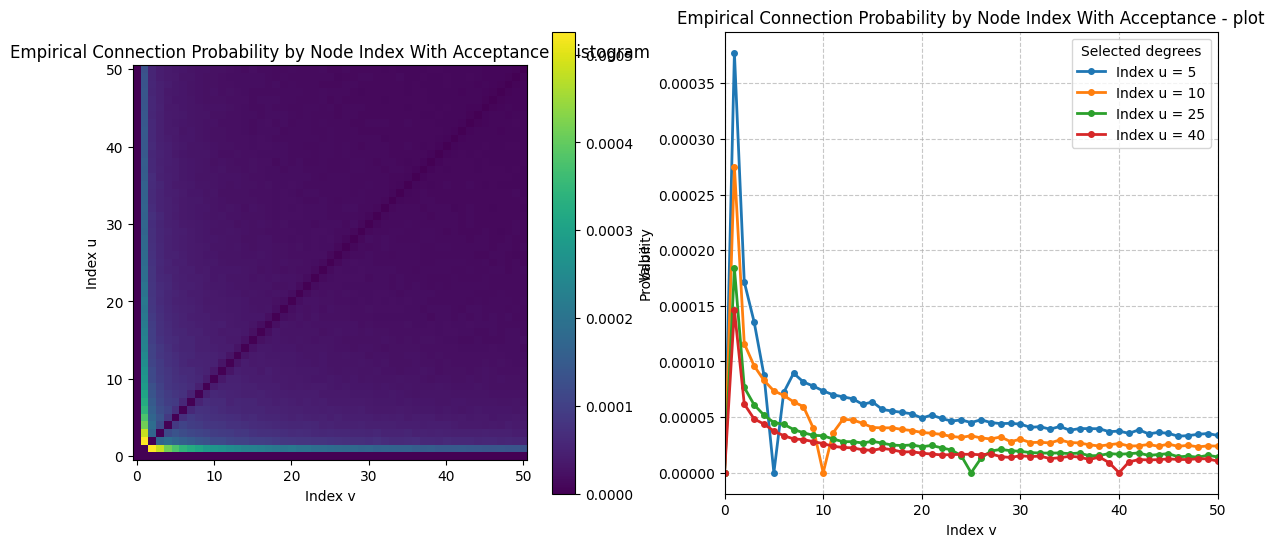

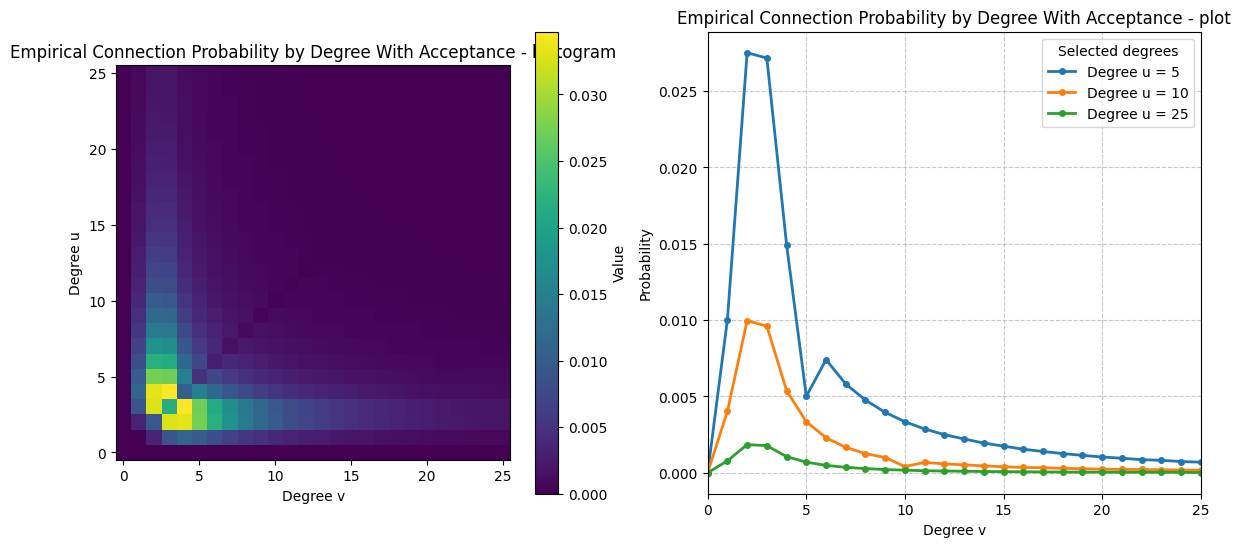

In [42]:
with open('generated-data/without-acceptance/preferential-attachment/empirical_nodes_connection_probability.pkl', 'rb') as f:
    empirical_nodes_connection_probability = pickle.load(f)
visualize_matrix(empirical_nodes_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Node Index', 'Index v', 'Index u', max_key=50)

with open('generated-data/without-acceptance/preferential-attachment/empirical_degrees_connection_probability.pkl', 'rb') as f:
    empirical_degrees_connection_probability = pickle.load(f)
visualize_matrix(empirical_degrees_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Degree', 'Degree v', 'Degree u', max_key=25)

with open('generated-data/with-acceptance/preferential-attachment/empirical_nodes_connection_probability.pkl', 'rb') as f:
    empirical_nodes_connection_probability = pickle.load(f)
visualize_matrix(empirical_nodes_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Node Index With Acceptance', 'Index v', 'Index u', max_key=50)

with open('generated-data/with-acceptance/preferential-attachment/empirical_degrees_connection_probability.pkl', 'rb') as f:
    empirical_degrees_connection_probability = pickle.load(f)
visualize_matrix(empirical_degrees_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Degree With Acceptance', 'Degree v', 'Degree u', max_key=25)

### Sublinear Preferential Attachment

In [21]:
empirical_nodes_connection_probability = calculate_empirical_nodes_connection_probability(lambda: generate_variate_graph(1000, 3, 1, 0.7, graph_type="power-based"), 10000)
with open('generated-data/without-acceptance/sublinear-preferential-attachment/empirical_nodes_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_nodes_connection_probability, f)

empirical_degrees_connection_probability = calculate_empirical_degrees_connection_probability(lambda: generate_variate_graph(1000, 3, 1, 0.7, graph_type="power-based"), 10000)
with open('generated-data/without-acceptance/sublinear-preferential-attachment/empirical_degrees_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_degrees_connection_probability, f)

empirical_nodes_connection_probability = calculate_empirical_nodes_connection_probability(lambda: generate_variate_graph(1000, 3, 0.6, 0.7, graph_type="power-based"), 10000)
with open('generated-data/with-acceptance/sublinear-preferential-attachment/empirical_nodes_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_nodes_connection_probability, f)

empirical_degrees_connection_probability = calculate_empirical_degrees_connection_probability(lambda: generate_variate_graph(1000, 3, 0.6, 0.7, graph_type="power-based"), 10000)
with open('generated-data/with-acceptance/sublinear-preferential-attachment/empirical_degrees_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_degrees_connection_probability, f)

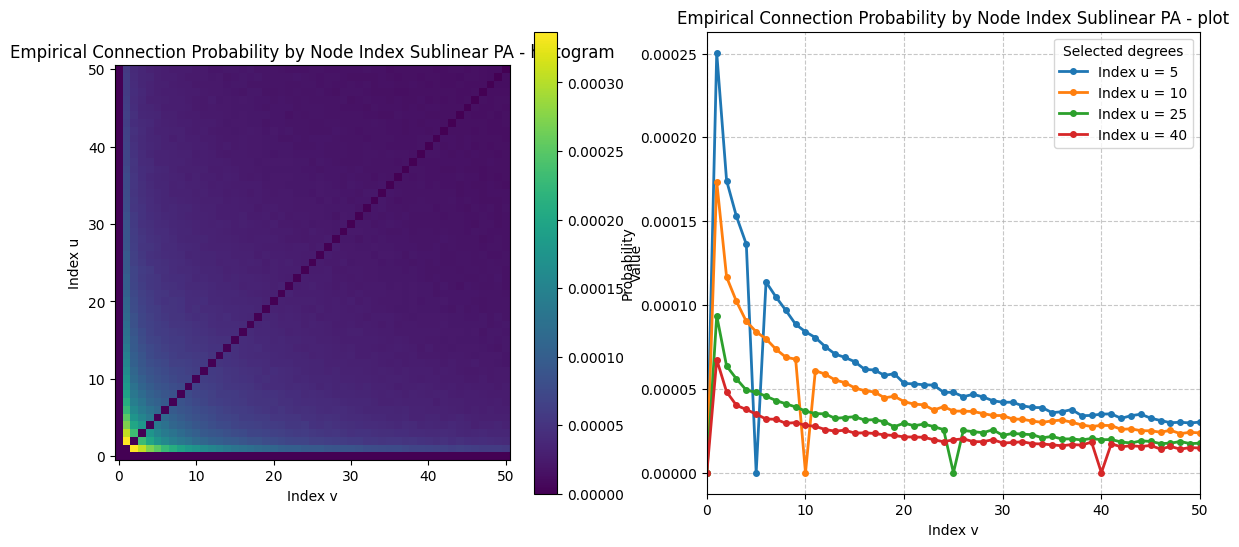

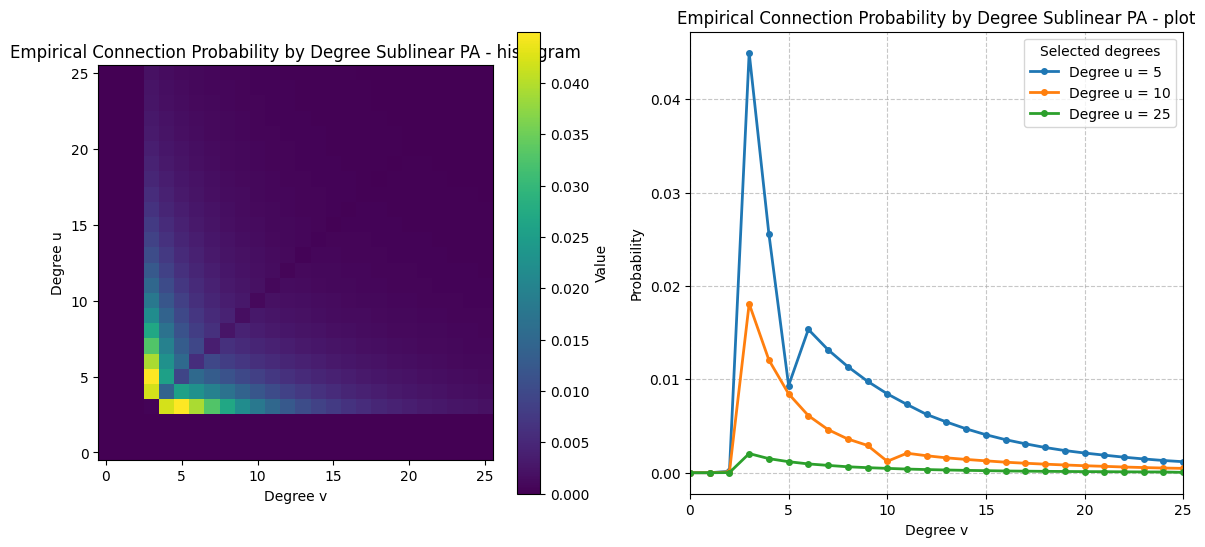

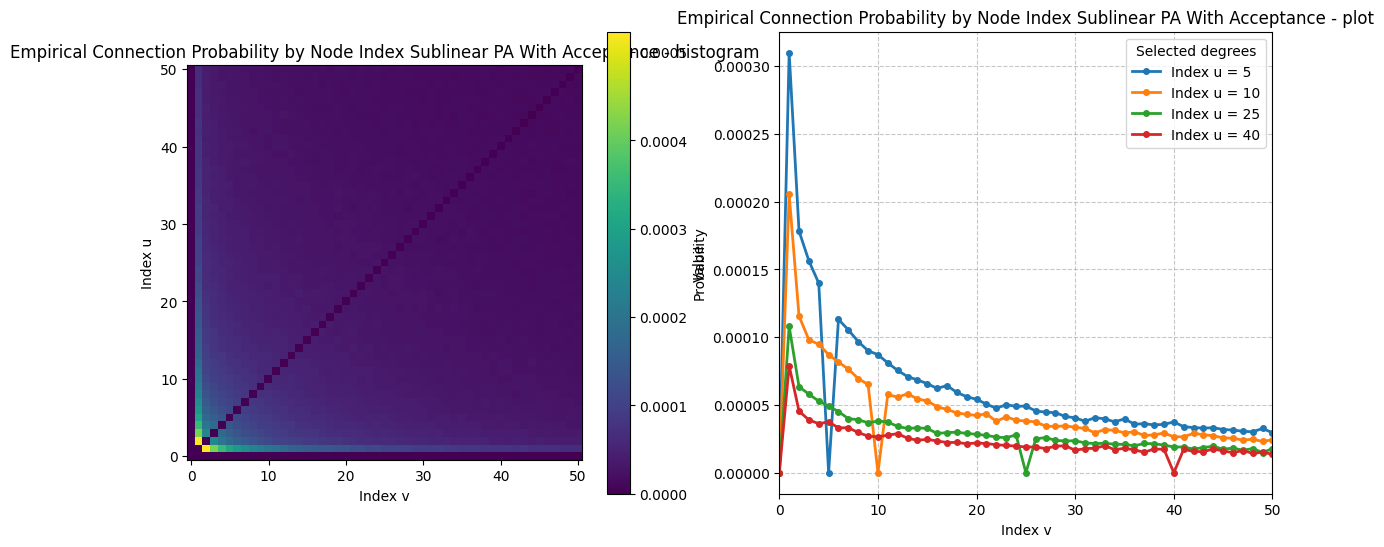

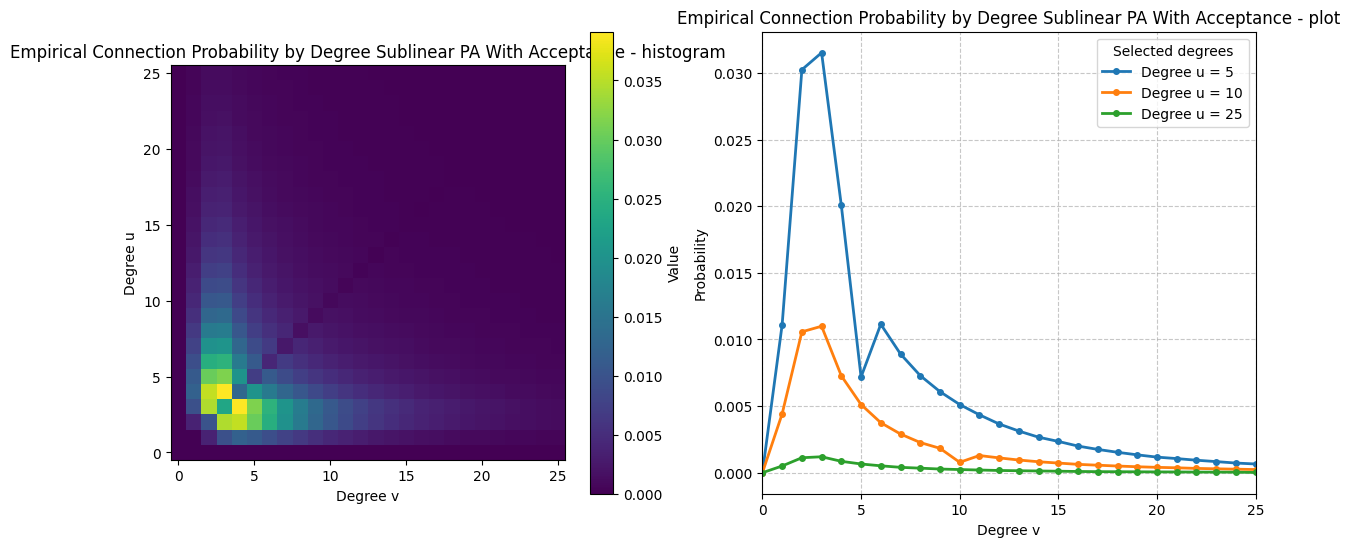

In [44]:
with open('generated-data/without-acceptance/sublinear-preferential-attachment/empirical_nodes_connection_probability.pkl', 'rb') as f:
    empirical_nodes_connection_probability = pickle.load(f)
visualize_matrix(empirical_nodes_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Node Index Sublinear PA', 'Index v', 'Index u', max_key=50)

with open('generated-data/without-acceptance/sublinear-preferential-attachment/empirical_degrees_connection_probability.pkl', 'rb') as f:
    empirical_degrees_connection_probability = pickle.load(f)
visualize_matrix(empirical_degrees_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Degree Sublinear PA', 'Degree v', 'Degree u', max_key=25)
with open('generated-data/with-acceptance/sublinear-preferential-attachment/empirical_nodes_connection_probability.pkl', 'rb') as f:
    empirical_nodes_connection_probability = pickle.load(f)
visualize_matrix(empirical_nodes_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Node Index Sublinear PA With Acceptance', 'Index v', 'Index u', max_key=50)

with open('generated-data/with-acceptance/sublinear-preferential-attachment/empirical_degrees_connection_probability.pkl', 'rb') as f:
    empirical_degrees_connection_probability = pickle.load(f)
visualize_matrix(empirical_degrees_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Degree Sublinear PA With Acceptance', 'Degree v', 'Degree u', max_key=25)

### Superlinear Preferential Attachment

In [45]:
empirical_nodes_connection_probability = calculate_empirical_nodes_connection_probability(lambda: generate_variate_graph(1000, 3, 1, 1.25, graph_type="power-based"), 10000)
with open('generated-data/without-acceptance/superlinear-preferential-attachment/empirical_nodes_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_nodes_connection_probability, f)

empirical_degrees_connection_probability = calculate_empirical_degrees_connection_probability(lambda: generate_variate_graph(1000, 3, 1, 1.25, graph_type="power-based"), 10000)
with open('generated-data/without-acceptance/superlinear-preferential-attachment/empirical_degrees_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_degrees_connection_probability, f)

empirical_nodes_connection_probability = calculate_empirical_nodes_connection_probability(lambda: generate_variate_graph(1000, 3, 0.6, 1.25, graph_type="power-based"), 10000)
with open('generated-data/with-acceptance/superlinear-preferential-attachment/empirical_nodes_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_nodes_connection_probability, f)

empirical_degrees_connection_probability = calculate_empirical_degrees_connection_probability(lambda: generate_variate_graph(1000, 3, 0.6, 1.25, graph_type="power-based"), 10000)
with open('generated-data/with-acceptance/superlinear-preferential-attachment/empirical_degrees_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_degrees_connection_probability, f)

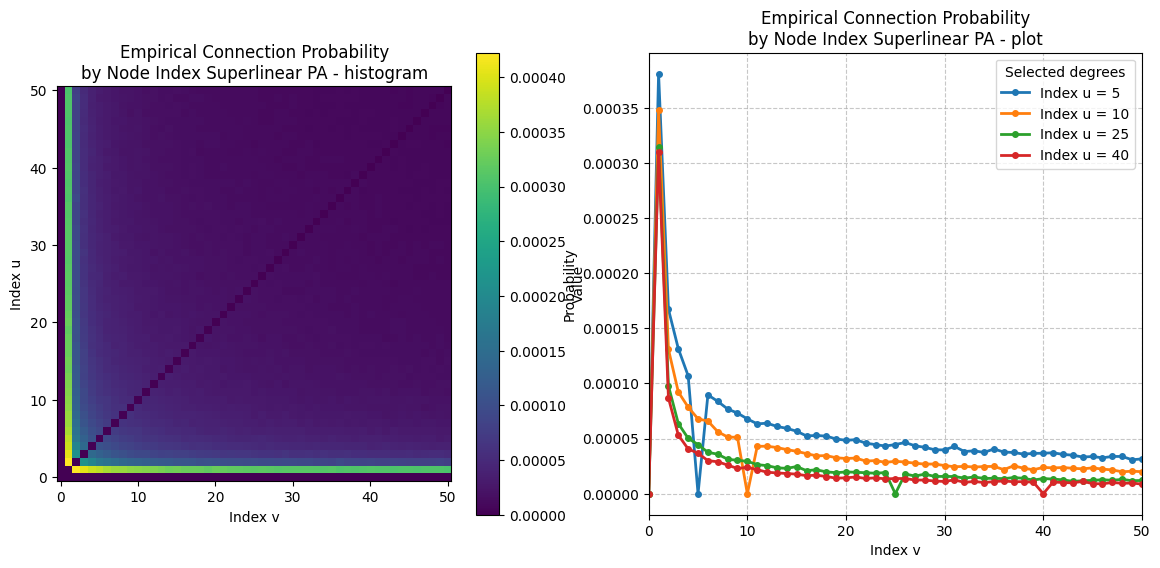

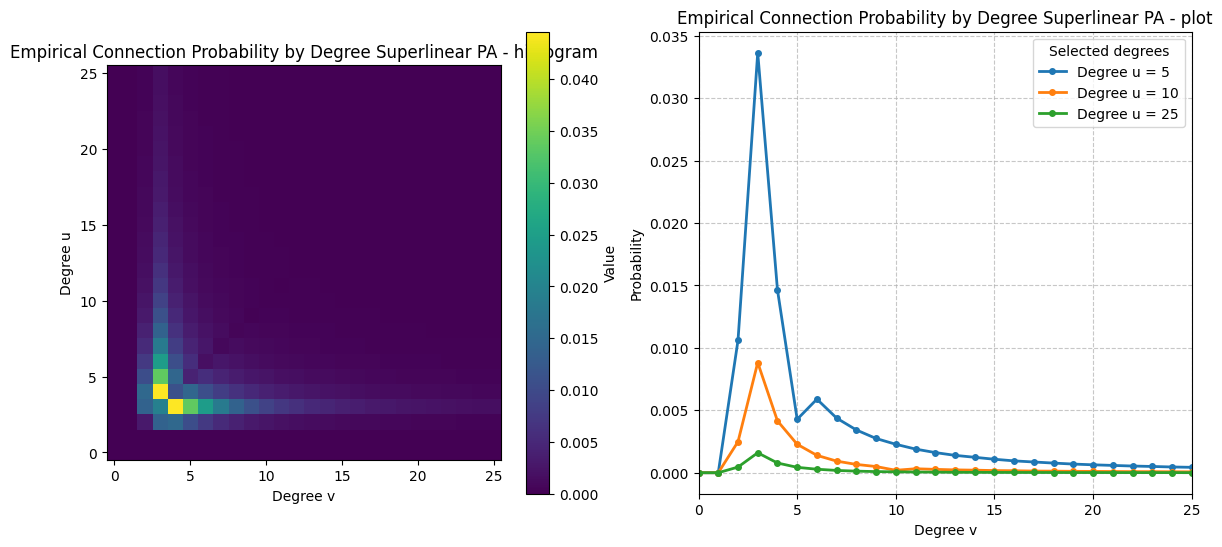

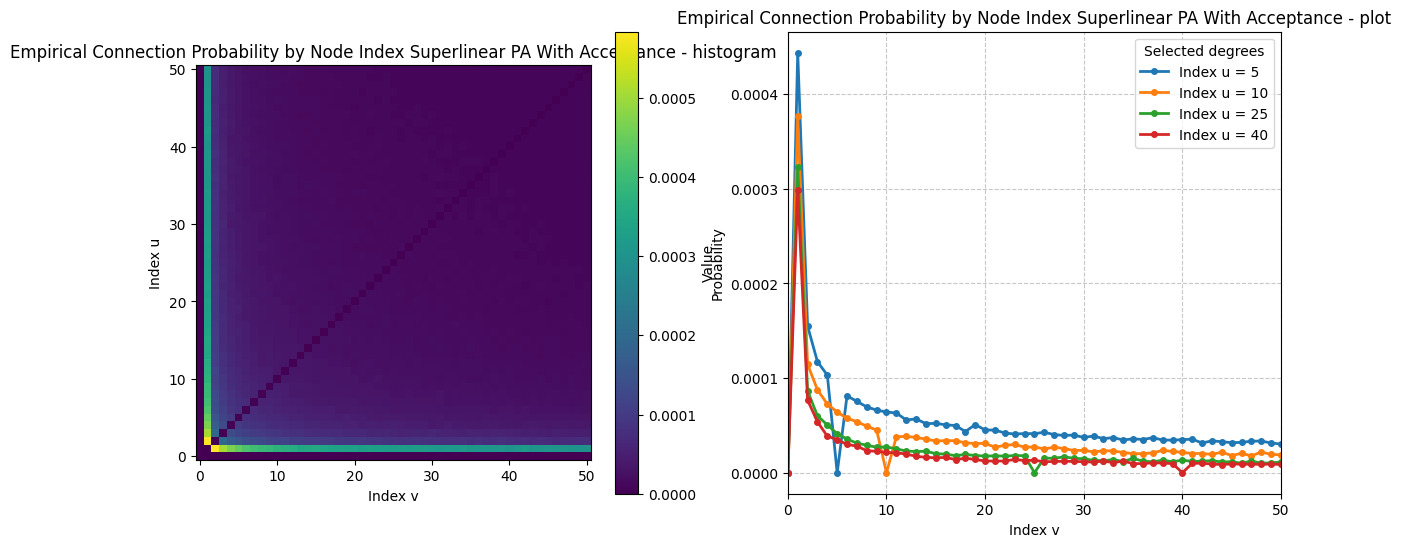

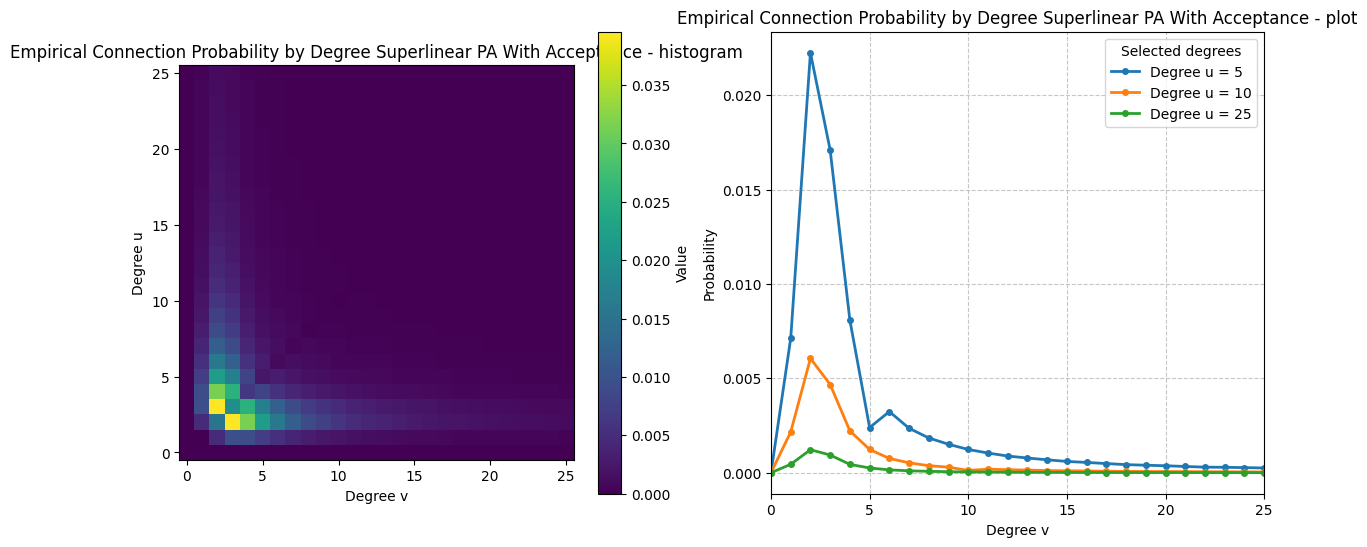

In [47]:
with open('generated-data/without-acceptance/superlinear-preferential-attachment/empirical_nodes_connection_probability.pkl', 'rb') as f:
    empirical_nodes_connection_probability = pickle.load(f)
visualize_matrix(empirical_nodes_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability\nby Node Index Superlinear PA', 'Index v', 'Index u', max_key=50)

with open('generated-data/without-acceptance/superlinear-preferential-attachment/empirical_degrees_connection_probability.pkl', 'rb') as f:
    empirical_degrees_connection_probability = pickle.load(f)
visualize_matrix(empirical_degrees_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Degree Superlinear PA', 'Degree v', 'Degree u', max_key=25)
with open('generated-data/with-acceptance/superlinear-preferential-attachment/empirical_nodes_connection_probability.pkl', 'rb') as f:
    empirical_nodes_connection_probability = pickle.load(f)
visualize_matrix(empirical_nodes_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Node Index Superlinear PA With Acceptance', 'Index v', 'Index u', max_key=50)

with open('generated-data/with-acceptance/superlinear-preferential-attachment/empirical_degrees_connection_probability.pkl', 'rb') as f:
    empirical_degrees_connection_probability = pickle.load(f)
visualize_matrix(empirical_degrees_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Degree Superlinear PA With Acceptance', 'Degree v', 'Degree u', max_key=25)

### Log Based Preferential Attachment

In [48]:
empirical_nodes_connection_probability = calculate_empirical_nodes_connection_probability(lambda: generate_variate_graph(1000, 3, 1, graph_type="log-based"), 10000)
with open('generated-data/without-acceptance/log-based-preferential-attachment/empirical_nodes_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_nodes_connection_probability, f)

empirical_degrees_connection_probability = calculate_empirical_degrees_connection_probability(lambda: generate_variate_graph(1000, 3, 1, graph_type="log-based"), 10000)
with open('generated-data/without-acceptance/log-based-preferential-attachment/empirical_degrees_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_degrees_connection_probability, f)

empirical_nodes_connection_probability = calculate_empirical_nodes_connection_probability(lambda: generate_variate_graph(1000, 3, 0.6, graph_type="log-based"), 10000)
with open('generated-data/with-acceptance/log-based-preferential-attachment/empirical_nodes_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_nodes_connection_probability, f)

empirical_degrees_connection_probability = calculate_empirical_degrees_connection_probability(lambda: generate_variate_graph(1000, 3, 0.6, graph_type="log-based"), 10000)
with open('generated-data/with-acceptance/log-based-preferential-attachment/empirical_degrees_connection_probability.pkl', 'wb') as f:
    pickle.dump(empirical_degrees_connection_probability, f)


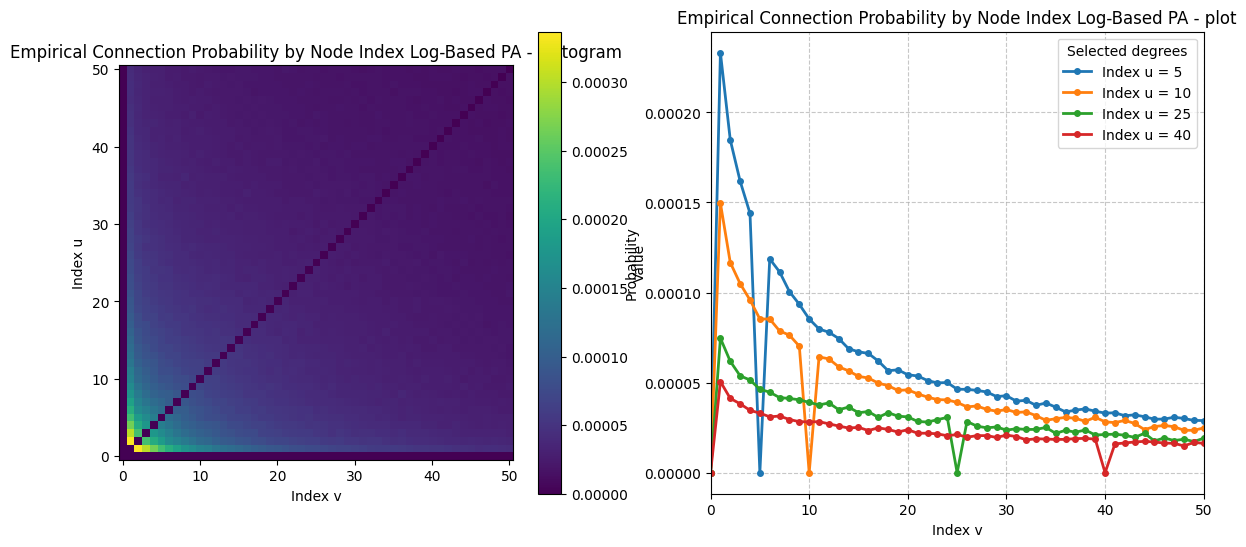

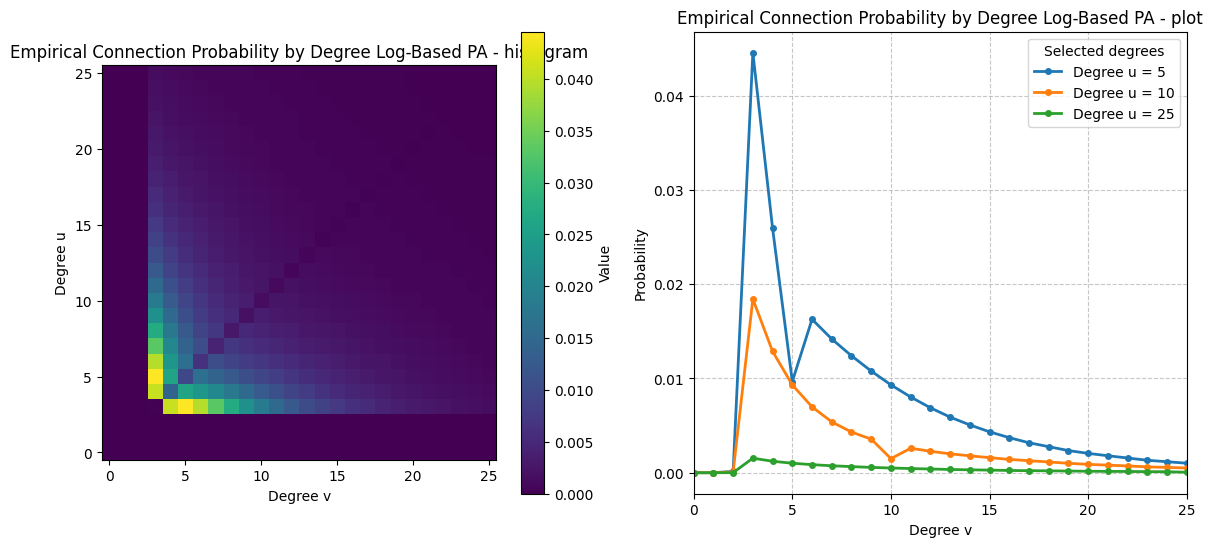

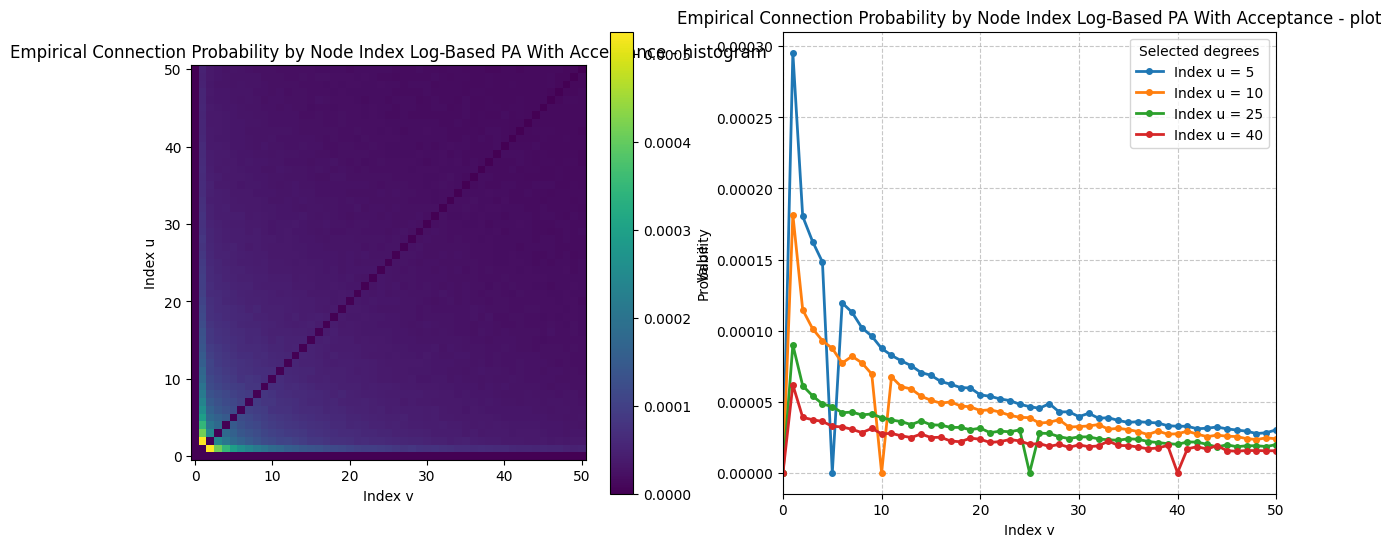

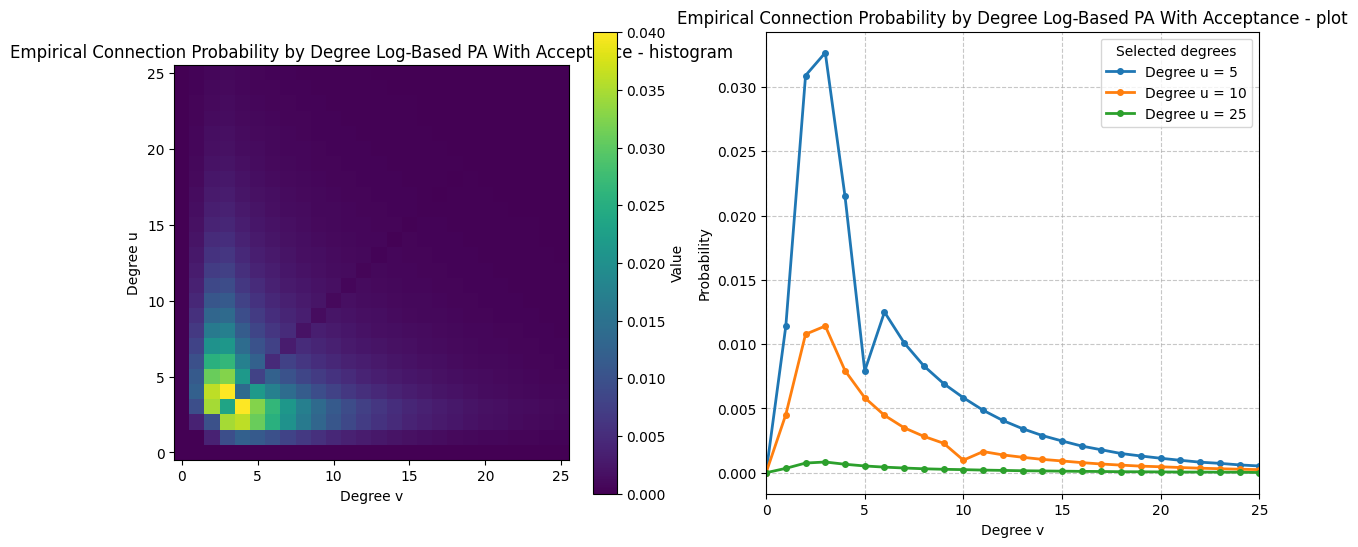

In [49]:
with open('generated-data/without-acceptance/log-based-preferential-attachment/empirical_nodes_connection_probability.pkl', 'rb') as f:
    empirical_nodes_connection_probability = pickle.load(f)
visualize_matrix(empirical_nodes_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Node Index Log-Based PA', 'Index v', 'Index u', max_key=50)

with open('generated-data/without-acceptance/log-based-preferential-attachment/empirical_degrees_connection_probability.pkl', 'rb') as f:
    empirical_degrees_connection_probability = pickle.load(f)
visualize_matrix(empirical_degrees_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Degree Log-Based PA', 'Degree v', 'Degree u', max_key=25)
with open('generated-data/with-acceptance/log-based-preferential-attachment/empirical_nodes_connection_probability.pkl', 'rb') as f:
    empirical_nodes_connection_probability = pickle.load(f)
visualize_matrix(empirical_nodes_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Node Index Log-Based PA With Acceptance', 'Index v', 'Index u', max_key=50)

with open('generated-data/with-acceptance/log-based-preferential-attachment/empirical_degrees_connection_probability.pkl', 'rb') as f:
    empirical_degrees_connection_probability = pickle.load(f)
visualize_matrix(empirical_degrees_connection_probability, [5, 10, 25, 40], 'Empirical Connection Probability by Degree Log-Based PA With Acceptance', 'Degree v', 'Degree u', max_key=25)

In [55]:
def calculate_structural_log_likelihood(G: nx.Graph, empirical_degrees_connection_probability: defaultdict) -> float:
    likelihood = 0
    for u, v in G.edges():
        deg_u = G.degree(u)
        deg_v = G.degree(v)

        if deg_u > deg_v:
            deg_u, deg_v = deg_v, deg_u

        if (deg_u, deg_v) in empirical_degrees_connection_probability:
            prob = empirical_degrees_connection_probability.get((deg_u, deg_v))
        else:
            neighbor_probs = []
            dist = 1
            while len(neighbor_probs) == 0:
                # |d1| + |d2| = dist
                for d1 in range(-dist, dist + 1):
                    for d2 in [dist - abs(d1), abs(d1) - dist]:
                        new_deg_u = deg_u + d1
                        new_deg_v = deg_v + d2

                        if new_deg_u > new_deg_v:
                            new_deg_u, new_deg_v = new_deg_v, new_deg_u

                        if (new_deg_u, new_deg_v) in empirical_degrees_connection_probability:
                            neighbor_probs.append(empirical_degrees_connection_probability[(new_deg_u, new_deg_v)])

                dist += 1
            prob = sum(neighbor_probs) / len(neighbor_probs)

        likelihood += np.log(prob)

    return likelihood

def compare_structural_log_likelihoods(G: nx.Graph, empirical_conn_probs: dict) -> dict:
    likelihoods = {}
    for model_name, emp_conn_prob in empirical_conn_probs.items():
        likelihood = calculate_structural_log_likelihood(G, emp_conn_prob)
        likelihoods[model_name] = likelihood

    return likelihoods, max(likelihoods, key=likelihoods.get)

In [56]:
with open('generated-data/without-acceptance/preferential-attachment/empirical_degrees_connection_probability.pkl', 'rb') as f:
    empirical_degrees_connection_probability = pickle.load(f)

with open('generated-data/without-acceptance/log-based-preferential-attachment/empirical_degrees_connection_probability.pkl', 'rb') as f:
    empirical_log_degrees_connection_probability = pickle.load(f)

with open('generated-data/with-acceptance/preferential-attachment/empirical_degrees_connection_probability.pkl', 'rb') as f:
    empirical_degrees_connection_with_acceptance_probability = pickle.load(f)

with open('generated-data/with-acceptance/log-based-preferential-attachment/empirical_degrees_connection_probability.pkl', 'rb') as f:
    empirical_log_degrees_connection_with_acceptance_probability = pickle.load(f)


g1 = generate_variate_graph(1000, 3, 1, graph_type="standard")
print("\nGraph 1 Structural Likelihoods:")
pprint.pprint(compare_structural_log_likelihoods(g1, {
    "Preferential Attachment": empirical_degrees_connection_probability,
    "Preferential Attachment With Acceptance": empirical_degrees_connection_with_acceptance_probability,
    "Log-Based Preferential Attachment": empirical_log_degrees_connection_probability,
    "Log-Based Preferential Attachment With Acceptance": empirical_log_degrees_connection_with_acceptance_probability
}))

g2 = generate_variate_graph(1000, 3, 1, graph_type="log-based")
print("\nGraph 2 Structural Likelihoods:")
pprint.pprint(compare_structural_log_likelihoods(g2, {
    "Preferential Attachment": empirical_degrees_connection_probability,
    "Preferential Attachment With Acceptance": empirical_degrees_connection_with_acceptance_probability,
    "Log-Based Preferential Attachment": empirical_log_degrees_connection_probability,
    "Log-Based Preferential Attachment With Acceptance": empirical_log_degrees_connection_with_acceptance_probability
}))

g3 = generate_variate_graph(1000, 3, 0.6, graph_type="standard")
print("\nGraph 3 Structural Likelihoods:")
pprint.pprint(compare_structural_log_likelihoods(g3, {
    "Preferential Attachment": empirical_degrees_connection_probability,
    "Preferential Attachment With Acceptance": empirical_degrees_connection_with_acceptance_probability,
    "Log-Based Preferential Attachment": empirical_log_degrees_connection_probability,
    "Log-Based Preferential Attachment With Acceptance": empirical_log_degrees_connection_with_acceptance_probability
}))

g4 = generate_variate_graph(1000, 3, 0.6, graph_type="log-based")
print("\nGraph 4 Structural Likelihoods:")
pprint.pprint(compare_structural_log_likelihoods(g4, {
    "Preferential Attachment": empirical_degrees_connection_probability,
    "Preferential Attachment With Acceptance": empirical_degrees_connection_with_acceptance_probability,
    "Log-Based Preferential Attachment": empirical_log_degrees_connection_probability,
    "Log-Based Preferential Attachment With Acceptance": empirical_log_degrees_connection_with_acceptance_probability
}))


Graph 1 Structural Likelihoods:
({'Log-Based Preferential Attachment': np.float64(-19097.917708895806),
  'Log-Based Preferential Attachment With Acceptance': np.float64(-20637.132207158218),
  'Preferential Attachment': np.float64(-17244.172810218257),
  'Preferential Attachment With Acceptance': np.float64(-18791.226082277728)},
 'Preferential Attachment')

Graph 2 Structural Likelihoods:
({'Log-Based Preferential Attachment': np.float64(-14901.251593254197),
  'Log-Based Preferential Attachment With Acceptance': np.float64(-16286.691639676568),
  'Preferential Attachment': np.float64(-15697.905525453389),
  'Preferential Attachment With Acceptance': np.float64(-17267.08316378418)},
 'Log-Based Preferential Attachment')

Graph 3 Structural Likelihoods:
({'Log-Based Preferential Attachment': np.float64(-15138.26301850981),
  'Log-Based Preferential Attachment With Acceptance': np.float64(-11540.013997867893),
  'Preferential Attachment': np.float64(-14014.869857691094),
  'Preferenti